# Transitions in Regions

In [6]:
import cmocean.cm as cm
import copy
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import matplotlib.gridspec as gridspec
import pandas as pd
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap
import matplotlib.dates as mdates
from shapely.geometry import Polygon, Point
from shapely.plotting import plot_polygon
from matplotlib.path import Path

In [2]:
from Regions_functions_V2 import polygon_S1, polygon_lon_lat_S1, polygon_N1, polygon_lon_lat_N1, polygon_N2, polygon_lon_lat_N2, polygon_N3, polygon_lon_lat_N3
from Regions_functions_V2 import polygon_S2, polygon_lon_lat_S2, polygon_C1, polygon_lon_lat_C1, polygon_SP, polygon_lon_lat_SP, polygon_HW1, polygon_lon_lat_HW1
from Regions_functions_V2 import polygon_F1, polygon_lon_lat_F1, polygon_H1, polygon_lon_lat_H1, polygon_J1, polygon_lon_lat_J1, polygon_S3, polygon_lon_lat_S3

In [7]:
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')
bathy = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc')

In [3]:
filename_y1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_1.nc'
filename_y2 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_2.nc'
filename_y3 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_3.nc'
filename_y4 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_4.nc'
filename_y5 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_5.nc'
filename_y6 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_6.nc'
filename_y7 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_7.nc'
filename_y8 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_8.nc'
filename_y9 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_9.nc'

In [52]:
data = xr.open_dataset(filename_y1)

# In Sediment

In [53]:
labels_sediment = ['S. S. - C. S.', 'S. C. - M. S.', 'M. S. - C. S.']

status = data.status.values
#
status_now = status[:, :-1]     # current timestep
status_next = status[:, 1:]     # next timestep
#
sediment_s_to_c = (status_now == 11) & (status_next == 12)
sediment_c_to_m = (status_now == 12) & (status_next == 13)
sediment_m_to_c = (status_now == 13) & (status_next == 12)

total_sediment_transitions = (
    np.count_nonzero(sediment_s_to_c) +
    np.count_nonzero(sediment_c_to_m) +
    np.count_nonzero(sediment_m_to_c)
)
#### Depths 
#
z = data.z.values  
z_now = z[:, :-1] 
#
depths_sediment_s_to_c = z_now[sediment_s_to_c]
depths_sediment_c_to_m = z_now[sediment_c_to_m]
depths_sediment_m_to_c = z_now[sediment_m_to_c]
#
depth_data_sediment = [
    depths_sediment_s_to_c, depths_sediment_c_to_m, depths_sediment_m_to_c
]
means_sediment = []
medians_sediment = []
mins_sediment = []
maxs_sediment = []
counts = []

for label, arr in zip(labels_sediment, depth_data_sediment):
    if arr.size > 0:
        means_sediment.append(arr.mean())
        medians_sediment.append(np.median(arr))
        mins_sediment.append(arr.min())
        maxs_sediment.append(arr.max())
        counts.append(arr.size)
        print(f'{label}: mean={arr.mean():.2f}, median={np.median(arr):.2f}, min={arr.min():.2f}, max={arr.max():.2f}, n={arr.size}')

#
#
# Percentage of sediment transitions
print(np.count_nonzero(sediment_s_to_c) / total_sediment_transitions * 100, '% sediment s_to_c')
print(np.count_nonzero(sediment_c_to_m) / total_sediment_transitions * 100, '% sediment c_to_m')
print(np.count_nonzero(sediment_m_to_c) / total_sediment_transitions * 100, '% sediment m_to_c')
#
percentage_sediment = [np.count_nonzero(sediment_s_to_c) / total_sediment_transitions * 100, 
           np.count_nonzero(sediment_c_to_m) / total_sediment_transitions * 100,
           np.count_nonzero(sediment_m_to_c) / total_sediment_transitions * 100]

S. C. - M. S.: mean=216.82, median=215.61, min=2.97, max=428.00, n=828741
M. S. - C. S.: mean=216.81, median=215.60, min=3.12, max=428.00, n=829821
0.0 % sediment s_to_c
49.967441675379035 % sediment c_to_m
50.032558324620965 % sediment m_to_c


# Resuspension Transitions

In [54]:
status = data.status.values
#
status_now = status[:, :-1]     # current timestep
status_next = status[:, 1:]     # next timestep
#
all_ss_to_c = (status_now == 11) & (status_next == 2)
all_cs_to_c = (status_now == 12) & (status_next == 2)
all_ms_to_c = (status_now == 13) & (status_next == 2)

#all_ss_to_m = (status_now == 11) & (status_next == 3)
all_cs_to_m = (status_now == 12) & (status_next == 3)
all_ms_to_m = (status_now == 13) & (status_next == 3)

total_resuspension_transitions = (
    np.count_nonzero(all_ss_to_c) +
    np.count_nonzero(all_cs_to_c) +
    np.count_nonzero(all_ms_to_c) +
    #np.count_nonzero(all_ss_to_m) +
    np.count_nonzero(all_cs_to_m) +
    np.count_nonzero(all_ms_to_m)
)

# Percentage of sediment transitions
print(np.count_nonzero(all_ss_to_c) / total_resuspension_transitions * 100, '% ss_to_c')
print(np.count_nonzero(all_cs_to_c) / total_resuspension_transitions * 100, '% cs_to_c')
print(np.count_nonzero(all_ms_to_c) / total_resuspension_transitions * 100, '% ms_to_c')
#print(np.count_nonzero(all_ss_to_m) / total_resuspension_transitions * 100, '% ss_to_m')
print(np.count_nonzero(all_cs_to_m) / total_resuspension_transitions * 100, '% cs_to_m')
print(np.count_nonzero(all_ms_to_m) / total_resuspension_transitions * 100, '% ms_to_m')

0.0 % ss_to_c
57.4276936002962 % cs_to_c
25.77993719916835 % ms_to_c
11.577212269659082 % cs_to_m
5.215156930876363 % ms_to_m


In [55]:
labels_res = ['S. S. - C. W. C.', 'C. S. - C. W. C.', 'M. S. - C. W. C.'
              #, 'S. S. to M.'
              , 'C. S. - M. W. C.', 'M. S - M. W. C.']
per_res = [np.count_nonzero(all_ss_to_c) / total_resuspension_transitions * 100, 
           np.count_nonzero(all_cs_to_c) / total_resuspension_transitions * 100,
           np.count_nonzero(all_ms_to_c) / total_resuspension_transitions * 100,
           #np.count_nonzero(all_ss_to_m) / total_resuspension_transitions * 100,
           np.count_nonzero(all_cs_to_m) / total_resuspension_transitions * 100,
           np.count_nonzero(all_ms_to_m) / total_resuspension_transitions * 100]
colors_res = ['k', 'r', 'g'
              #, 'k'
              , 'r', 'g']

In [56]:
z = data.z.values  

z_now = z[:, :-1] 


depths_ss_to_c = z_now[all_ss_to_c]
depths_cs_to_c = z_now[all_cs_to_c]
depths_ms_to_c = z_now[all_ms_to_c]

#depths_ss_to_m = z_now[all_ss_to_m]
depths_cs_to_m = z_now[all_cs_to_m]
depths_ms_to_m = z_now[all_ms_to_m]

#
depth_data = [
    depths_ss_to_c, depths_cs_to_c, depths_ms_to_c
    #,depths_ss_to_m
    , depths_cs_to_m, depths_ms_to_m
]
means = []
medians = []
mins = []
maxs = []
counts = []

for label, arr in zip(labels_res, depth_data):
    if arr.size > 0:
        means.append(arr.mean())
        medians.append(np.median(arr))
        mins.append(arr.min())
        maxs.append(arr.max())
        counts.append(arr.size)
        print(f'{label}: mean={arr.mean():.2f}, median={np.median(arr):.2f}, min={arr.min():.2f}, max={arr.max():.2f}, n={arr.size}')
    else:
        means.append(np.nan)
        medians.append(np.nan)
        mins.append(np.nan)
        maxs.append(np.nan)
        counts.append(0)
        print(f'{label}: No transitions')
#


S. S. - C. W. C.: No transitions
C. S. - C. W. C.: mean=218.40, median=202.35, min=3.52, max=428.00, n=1290460
M. S. - C. W. C.: mean=218.73, median=202.63, min=2.97, max=428.00, n=579302
C. S. - M. W. C.: mean=218.55, median=202.66, min=4.77, max=428.00, n=260152
M. S - M. W. C.: mean=218.17, median=200.93, min=9.76, max=428.00, n=117190


# Water Column Transitions

In [57]:
labels_water = ['S. W.C. - C. W. C.', 'C. W.C. - M. W. C.', 'M. W.C. - C. W. C.']

status = data.status.values
#
status_now = status[:, :-1]     # current timestep
status_next = status[:, 1:]     # next timestep
#
water_s_to_c = (status_now == 1) & (status_next == 2)
water_c_to_m = (status_now == 2) & (status_next == 3)
water_m_to_c = (status_now == 3) & (status_next == 2)

total_water_transitions = (
    np.count_nonzero(water_s_to_c) +
    np.count_nonzero(water_c_to_m) +
    np.count_nonzero(water_m_to_c)
)
#### Depths 
#
z = data.z.values  
z_now = z[:, :-1] 
#
depths_water_s_to_c = z_now[water_s_to_c]
depths_water_c_to_m = z_now[water_c_to_m]
depths_water_m_to_c = z_now[water_m_to_c]
#
depth_data_water = [
    depths_water_s_to_c, depths_water_c_to_m, depths_water_m_to_c
]
means_water = []
medians_water = []
mins_water = []
maxs_water = []
counts = []

for label, arr in zip(labels_water, depth_data_water):
    if arr.size > 0:
        means_water.append(arr.mean())
        medians_water.append(np.median(arr))
        mins_water.append(arr.min())
        maxs_water.append(arr.max())
        counts.append(arr.size)
        print(f'{label}: mean={arr.mean():.2f}, median={np.median(arr):.2f}, min={arr.min():.2f}, max={arr.max():.2f}, n={arr.size}')

#
#
# Percentage of water transitions
print(np.count_nonzero(water_s_to_c) / total_water_transitions * 100, '% water s_to_c')
print(np.count_nonzero(water_c_to_m) / total_water_transitions * 100, '% water c_to_m')
print(np.count_nonzero(water_m_to_c) / total_water_transitions * 100, '% water m_to_c')
#
percentage_water = [np.count_nonzero(water_s_to_c) / total_water_transitions * 100, 
           np.count_nonzero(water_c_to_m) / total_water_transitions * 100,
           np.count_nonzero(water_m_to_c) / total_water_transitions * 100]

S. W.C. - C. W. C.: mean=73.40, median=73.27, min=69.48, max=79.23, n=10
C. W.C. - M. W. C.: mean=248.92, median=240.38, min=0.00, max=428.00, n=5963762
M. W.C. - C. W. C.: mean=249.05, median=240.46, min=0.00, max=427.99, n=5960436
8.38630121178698e-05 % water s_to_c
50.01390448740914 % water c_to_m
49.986011649578735 % water m_to_c


# Sedimentation

In [58]:
labels_w_s = ['S. W.C. - S. S.', 'C. W.C. - C. S. ', 'M. W.C. - M. S.']

status = data.status.values
#
status_now = status[:, :-1]     # current timestep
status_next = status[:, 1:]     # next timestep
#
water_s_to_ss = (status_now == 1) & (status_next == 11)
water_c_to_cs = (status_now == 2) & (status_next == 12)
water_m_to_ms = (status_now == 3) & (status_next == 13)

total_sedimentation_transitions = (
    np.count_nonzero(water_s_to_ss) +
    np.count_nonzero(water_c_to_cs) +
    np.count_nonzero(water_m_to_ms)
)
#### Depths 
#
z = data.z.values  
z_now = z[:, :-1] 
#
depths_water_s_to_ss = z_now[water_s_to_ss]
depths_water_c_to_cs = z_now[water_c_to_cs]
depths_water_m_to_ms = z_now[water_m_to_ms]
#
depth_data_sedimentation = [
    depths_water_s_to_ss, depths_water_c_to_cs, depths_water_m_to_ms
]
means_sedimentation = []
medians_sedimentation = []
mins_sedimentation = []
maxs_sedimentation = []
counts = []

for label, arr in zip(labels_w_s, depth_data_sedimentation):
    if arr.size > 0:
        means_sedimentation.append(arr.mean())
        medians_sedimentation.append(np.median(arr))
        mins_sedimentation.append(arr.min())
        maxs_sedimentation.append(arr.max())
        counts.append(arr.size)
        print(f'{label}: mean={arr.mean():.2f}, median={np.median(arr):.2f}, min={arr.min():.2f}, max={arr.max():.2f}, n={arr.size}')

#
#
# Percentage of water transitions
print(np.count_nonzero(water_s_to_ss) / total_sedimentation_transitions * 100, '% water s_to_ss')
print(np.count_nonzero(water_c_to_cs) / total_sedimentation_transitions * 100, '% water c_to_cs')
print(np.count_nonzero(water_m_to_ms) / total_sedimentation_transitions * 100, '% water m_to_ms')
#
percentage_sedimentation = [np.count_nonzero(water_s_to_ss) / total_sedimentation_transitions * 100, 
           np.count_nonzero(water_c_to_cs) / total_sedimentation_transitions * 100,
           np.count_nonzero(water_m_to_ms) / total_sedimentation_transitions * 100]

C. W.C. - C. S. : mean=218.48, median=203.78, min=0.00, max=428.00, n=1289783
M. W.C. - M. S.: mean=219.02, median=205.97, min=7.54, max=427.99, n=118652
0.0 % water s_to_ss
91.57561406809685 % water c_to_cs
8.42438593190314 % water m_to_ms


# Plot :D

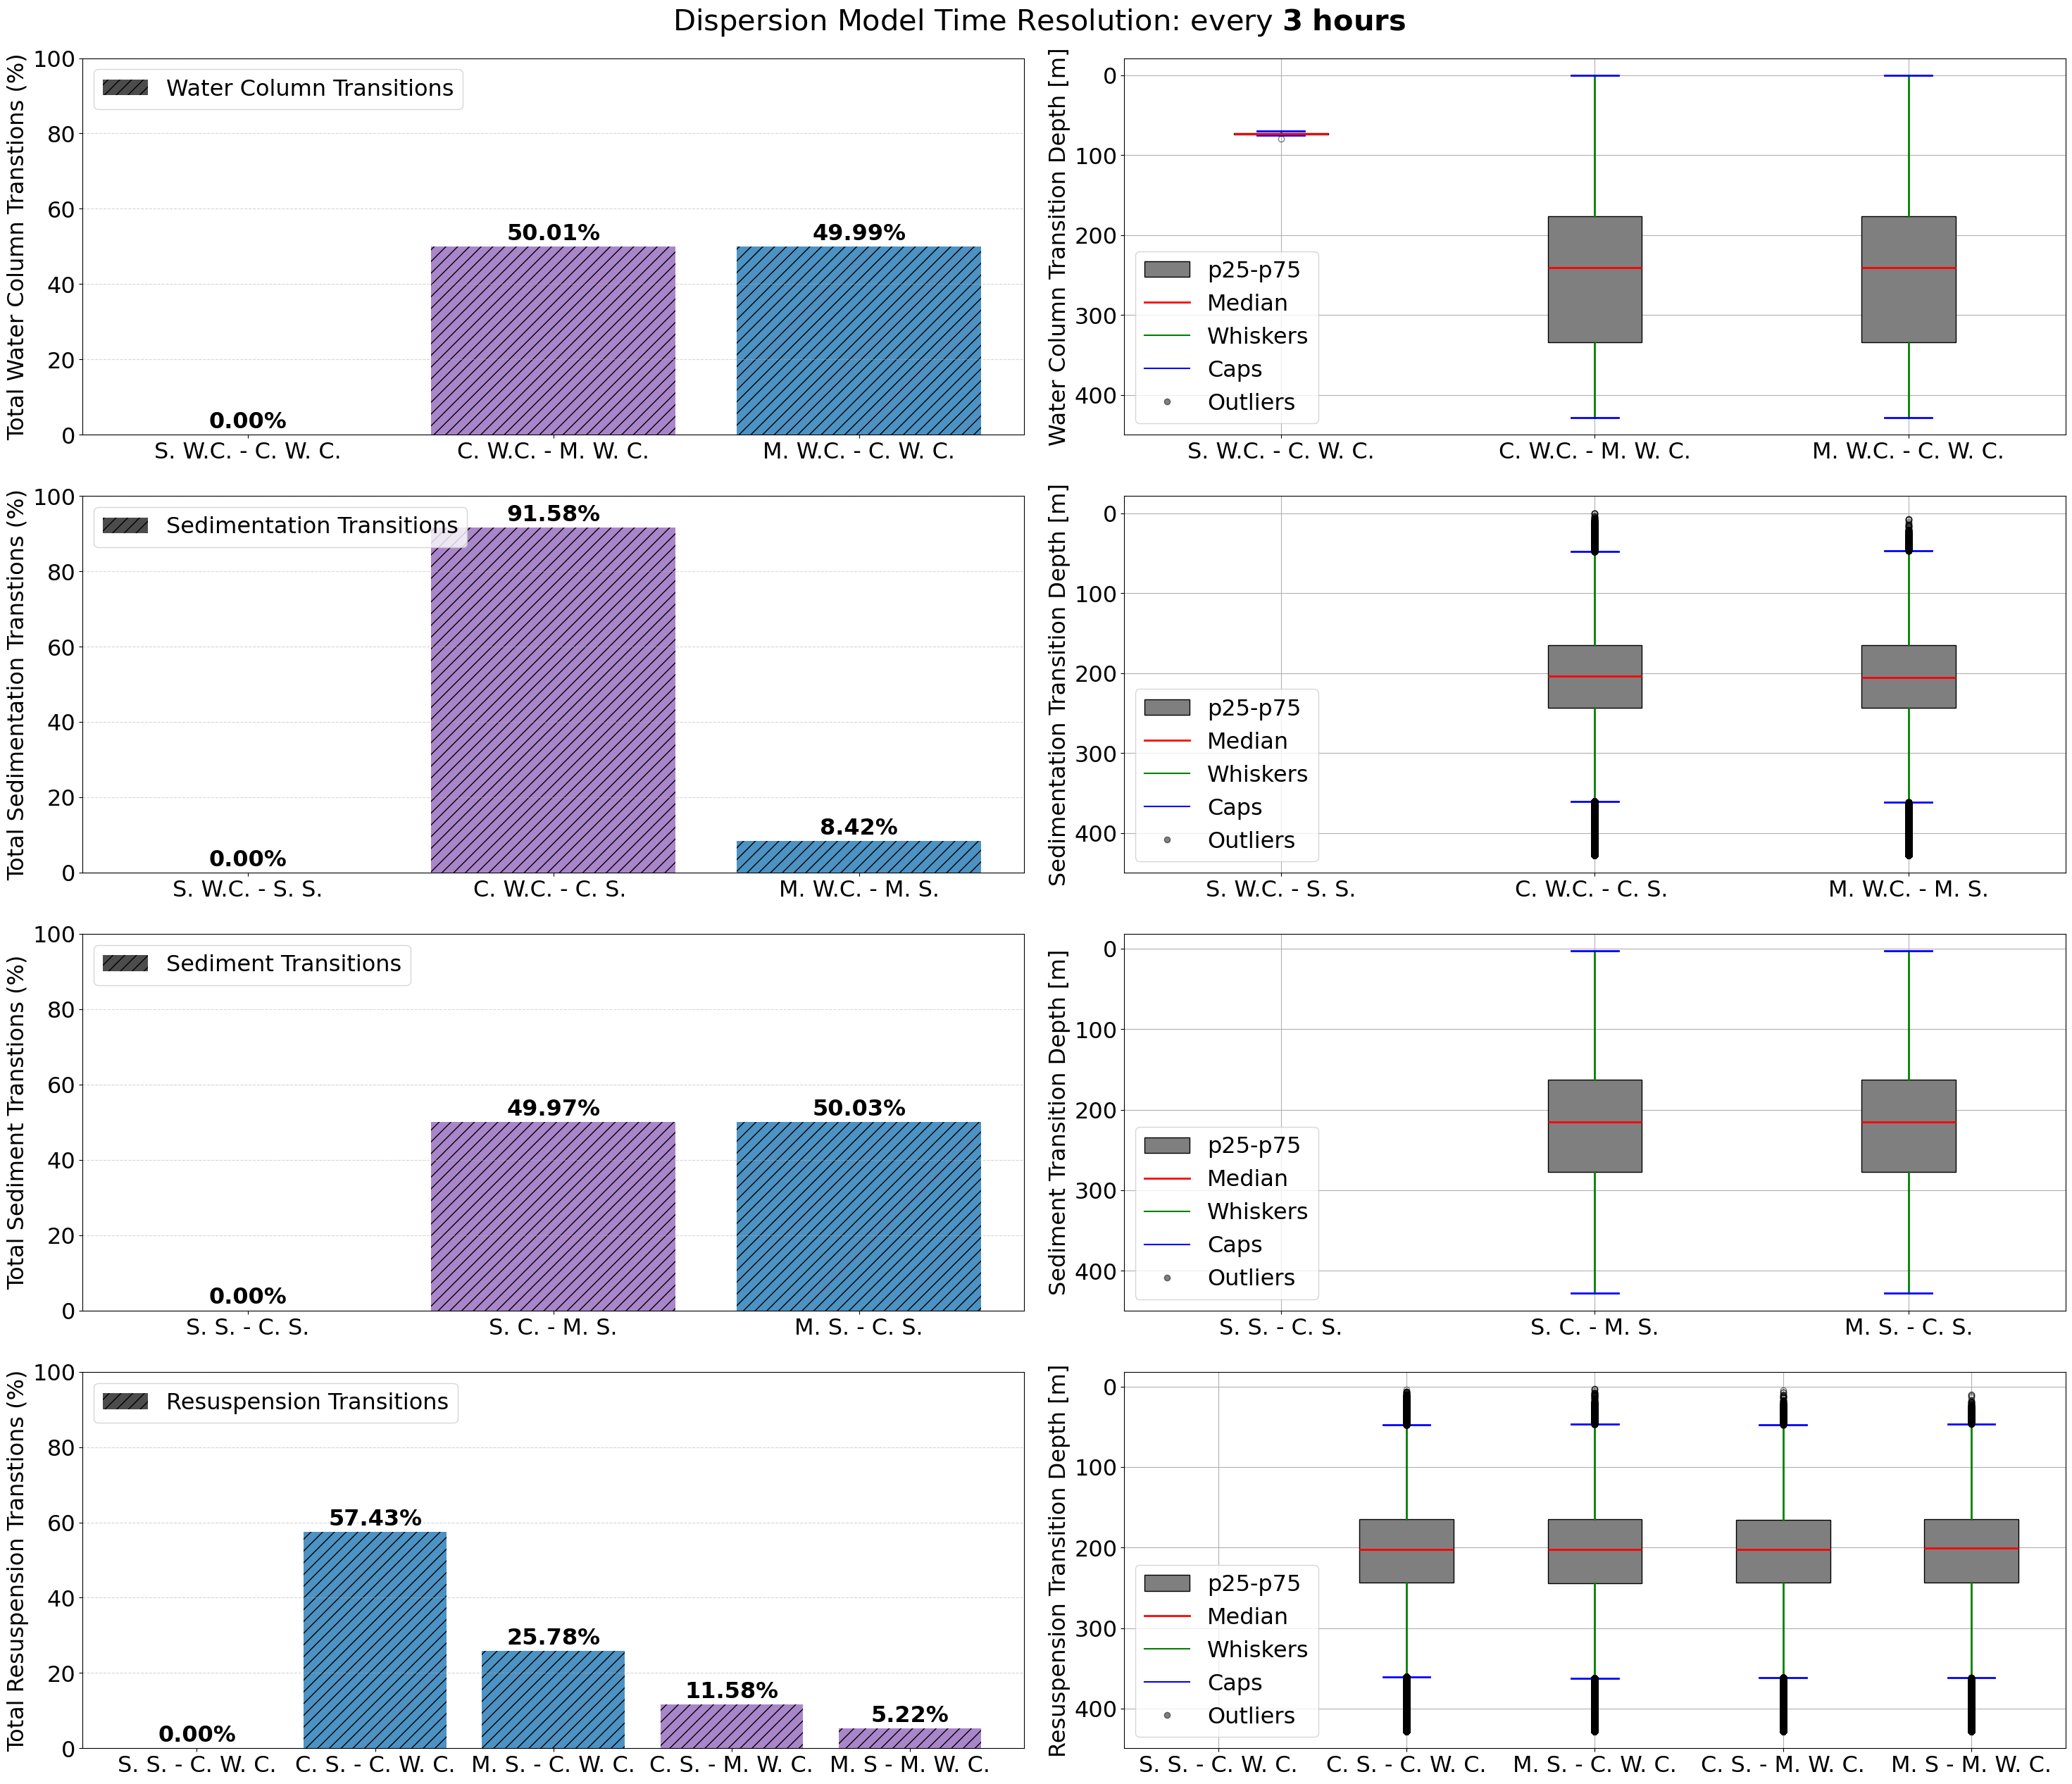

In [59]:
plt.rcParams.update({'font.size': 23})
#
fig, ax = plt.subplots(4,2,figsize=(30, 26), height_ratios=[1, 1, 1, 1])
#
### IN THE WATER COLUMN TRANSITIONS
ax[0, 0].bar(labels_water[0], percentage_water[0], color = 'k', hatch = '//', alpha = .7, label = 'Water Column Transitions')
bars1_water = ax[0, 0].bar(labels_water, percentage_water, color = ['tab:blue', 'tab:purple', 'tab:blue'], hatch = '//', alpha = .8)
#
for bar, value in zip(bars1_water, percentage_water):
    ax[0,0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5, 
        f'{value:.2f}%',
        ha='center', va='bottom', fontweight='bold'
    )
    #
ax[0,0].set_ylabel('Total Water Column Transtions (%)')
ax[0,0].set_ylim([0, 100]) 
ax[0,0].grid(axis='y', linestyle='--', alpha=0.5)
ax[0,0].legend(loc = 'upper left')
######
ax[0,1].boxplot(depth_data_water, labels=labels_water, patch_artist=True,
                boxprops=dict(facecolor='tab:grey', color='k'),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='green', linewidth=2),
                capprops=dict(color='blue', linewidth=2),
                flierprops=dict(marker='o', color='k', alpha=0.5))

ax[0,1].invert_yaxis()
ax[0,1].grid()
ax[0,1].set_ylabel('Water Column Transition Depth [m]')
#
### RESUSPENSION TRANSITIONS
ax[3, 0].bar(labels_res[0], per_res[0], color = 'k', hatch = '//', alpha = .7, label = 'Resuspension Transitions')
bars1_resuspension = ax[3, 0].bar(labels_res, per_res, color = ['tab:blue', 'tab:blue', 'tab:blue', 'tab:purple', 'tab:purple'], hatch = '//', alpha = .8)
#
for bar, value in zip(bars1_resuspension, per_res):
    ax[3,0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5, 
        f'{value:.2f}%',
        ha='center', va='bottom', fontweight='bold'
    )

ax[3,0].set_ylabel('Total Resuspension Transtions (%)')
ax[3,0].set_ylim([0, 100]) 
ax[3,0].grid(axis='y', linestyle='--', alpha=0.5)
ax[3,0].legend(loc = 'upper left')
######
ax[3,1].boxplot(depth_data, labels=labels_res, patch_artist=True,
                boxprops=dict(facecolor='tab:grey', color='k'),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='green', linewidth=2),
                capprops=dict(color='blue', linewidth=2),
                flierprops=dict(marker='o', color='k', alpha=0.5))

ax[3,1].invert_yaxis()
ax[3,1].grid()
ax[3,1].set_ylabel('Resuspension Transition Depth [m]')
### IN THE SEDIMENT TRANSITIONS
ax[2, 0].bar(labels_sediment[0], percentage_sediment[0], color = 'k', hatch = '//', alpha = .7, label = 'Sediment Transitions')
bars1_sediment = ax[2, 0].bar(labels_sediment, percentage_sediment, color = ['tab:blue', 'tab:purple', 'tab:blue'], hatch = '//', alpha = .8)
#
for bar, value in zip(bars1_sediment, percentage_sediment):
    ax[2,0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5, 
        f'{value:.2f}%',
        ha='center', va='bottom', fontweight='bold'
    )

ax[2,0].set_ylabel('Total Sediment Transtions (%)')
ax[2,0].set_ylim([0, 100]) 
ax[2,0].grid(axis='y', linestyle='--', alpha=0.5)
ax[2,0].legend(loc = 'upper left')
######
ax[2,1].boxplot(depth_data_sediment, labels=labels_sediment, patch_artist=True,
                boxprops=dict(facecolor='tab:grey', color='k'),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='green', linewidth=2),
                capprops=dict(color='blue', linewidth=2),
                flierprops=dict(marker='o', color='k', alpha=0.5))

ax[2,1].invert_yaxis()
ax[2,1].grid()
ax[2,1].set_ylabel('Sediment Transition Depth [m]')
####
#### SEDIMENTATION ####
ax[1, 0].bar(labels_w_s[0], percentage_sedimentation[0], color = 'k', hatch = '//', alpha = .7, label = 'Sedimentation Transitions')
bars1_sedimentation = ax[1, 0].bar(labels_w_s, percentage_sedimentation, color = ['tab:blue', 'tab:purple', 'tab:blue'], hatch = '//', alpha = .8)
#
for bar, value in zip(bars1_sedimentation, percentage_sedimentation):
    ax[1,0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5, 
        f'{value:.2f}%',
        ha='center', va='bottom', fontweight='bold'
    )

ax[1,0].set_ylabel('Total Sedimentation Transtions (%)')
ax[1,0].set_ylim([0, 100]) 
ax[1,0].grid(axis='y', linestyle='--', alpha=0.5)
ax[1,0].legend(loc = 'upper left')
######
ax[1,1].boxplot(depth_data_sedimentation, labels=labels_w_s, patch_artist=True,
                boxprops=dict(facecolor='tab:grey', color='k'),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='green', linewidth=2),
                capprops=dict(color='blue', linewidth=2),
                flierprops=dict(marker='o', color='k', alpha=0.5))

ax[1,1].invert_yaxis()
ax[1,1].grid()
ax[1,1].set_ylabel('Sedimentation Transition Depth [m]')
# # # # # #
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='tab:grey', edgecolor='k', label='p25-p75'),
    Line2D([0], [0], color='red', lw=2, label='Median'),
    Line2D([0], [0], color='green', lw=1.5, label='Whiskers'),
    Line2D([0], [0], color='blue', lw=1.5, label='Caps'),
    Line2D([0], [0], marker='o', color='k', linestyle='None', alpha=0.5, label='Outliers')
]

# Add legend to each right-column subplot
for i in [0,1,2,3]:
    ax[i,1].legend(handles=legend_elements, loc='lower left')
    #
plt.suptitle(r'Dispersion Model Time Resolution: every $\bf{3}$ $\bf{hours}$', fontsize = 30)
#
plt.tight_layout()
plt.show()